# ASAP8 Detection of Change analysis

Compact DoC notebook for optical-spike image variability and longitudinal image-response timing. Standalone anatomical depth analyses live in the separate depth notebook.

In [1]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage
from matplotlib.lines import Line2D
from IPython.display import display, HTML

from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.dataset import DEPTH_GROUP_ORDER, build_voltage_session_table, build_voltage_roi_table
from vip_slap2_analysis.voltage.spikes import DETECTOR_VERSION, build_spike_table
from vip_slap2_analysis.behavior.change_detection import build_change_detection_events
from vip_slap2_analysis.voltage.responses import build_single_trial_index, load_response_package, get_mean_response, get_sequence_response, load_single_trial_traces
from vip_slap2_analysis.behavior.encoder import compute_encoder_velocity

assert DETECTOR_VERSION == "template_v1"
sns.set_style("white")
plt.rcParams.update({"legend.fontsize":"x-large","axes.labelsize":"xx-large","axes.titlesize":"xx-large","xtick.labelsize":"xx-large","ytick.labelsize":"xx-large"})
display(HTML("<style>.container { width:100% !important; }</style>"))

## Configuration

In [2]:
BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")
SAVE_PATH = Path(r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots")
TARGET_MICE = [852835, 863774]
TARGET_SESSION_LABELS = None
TARGET_SESSION_IDS = None
PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]
TRACE_VARIANT = "dff_robust_f0_trial"
REGISTRATION_FILENAME = "roi_identity_registration.csv"
EXCLUDE_INVALID_ROIS = True
EXPECTED_F0_SMOOTH_SEC = 60.0
FORCE_SPIKE_RECOMPUTE = False
SPIKE_KWARGS = dict(height_sigma=3.0, template_sigma=3.5, prominence_sigma=0.5)
RUNNING_KWARGS = dict(wheel_radius_cm=4.69, encoder_units="ticks", ticks_per_revolution=8192, absolute_velocity=True)

SESSION_ORDER = ["A0","A1","A2","B0","B1","B2"]
IMAGE_WINDOW_S = (0.0, 0.25)
MIN_TRIALS_PER_IMAGE = 5
PEAK_WINDOW_S = (-0.25, 0.50)
PEAK_SMOOTH_MS = 10.0
DEPTH_COLORS = {"<100 µm":"#EBA287","100–150 µm":"#d1e2b0",">150 µm":"#7bbcd5"}
MOUSE_MARKERS = {str(m): marker for m, marker in zip(TARGET_MICE, ["o","s","^","D"])}

## Canonical DoC tables

In [3]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)
sessions = build_voltage_session_table(registry, subject_ids=TARGET_MICE, paradigms=PARADIGMS, exclude_session_types=EXCLUDE_SESSION_TYPES, session_labels=TARGET_SESSION_LABELS, session_ids=TARGET_SESSION_IDS, trace_variant=TRACE_VARIANT, expected_f0_smooth_sec=EXPECTED_F0_SMOOTH_SEC)
rois = build_voltage_roi_table(sessions, registration_filename=REGISTRATION_FILENAME, exclude_invalid_rois=EXCLUDE_INVALID_ROIS)
spikes = build_spike_table(sessions, rois, force=FORCE_SPIKE_RECOMPUTE, detection_kwargs=SPIKE_KWARGS)
events = build_change_detection_events(sessions)
trial_index = build_single_trial_index(sessions, events)

print(f"{len(sessions)} sessions · {rois['included'].sum()} included ROI observations · {len(spikes):,} spikes · {len(events):,} image cycles")
display(sessions[["subject_id","session_id","session_label","session_order","dmd1_depth_um","dmd2_depth_um"]])

C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\src\vip_slap2_analysis\voltage\dataset.py:203: UserWarning: 852835_2026-07-24_12-13-41: F0 smoother is 10 s, expected 60 s
  warnings.warn(


13 sessions · 99 included ROI observations · 1,039,642 spikes · 29,797 image cycles


,subject_id,session_id,session_label,session_order,dmd1_depth_um,dmd2_depth_um
0,852835,852835_2026-07-23_14-27-27,A0,0,40.0,170.0
1,852835,852835_2026-07-24_12-13-41,A1,1,40.0,170.0
2,852835,852835_2026-07-27_11-59-54,A2,2,40.0,170.0
3,852835,852835_2026-07-28_17-13-56,B0,3,40.0,170.0
4,852835,852835_2026-07-29_10-08-37,B1,4,40.0,170.0
5,852835,852835_2026-07-30_15-04-34,B2,5,40.0,170.0
6,852835,852835_2026-08-01_14-58-35,G1,6,40.0,170.0
7,863774,863774_2026-08-04_08-12-47,A0,0,190.0,120.0
8,863774,863774_2026-08-05_13-17-41,A1,1,190.0,120.0
9,863774,863774_2026-08-06_09-15-41,A2,2,190.0,120.0


## Image-response peak latency

In [4]:
def smooth_finite(y, sigma):
    y = np.asarray(y,float).reshape(-1); good = np.isfinite(y)
    if good.sum() < 3: return np.full_like(y,np.nan)
    y = np.interp(np.arange(y.size),np.flatnonzero(good),y[good])
    return ndimage.gaussian_filter1d(y,sigma,mode="nearest")

selected = sessions[sessions["session_label"].astype(str).isin(SESSION_ORDER)]
available_labels = [s for s in SESSION_ORDER if s in set(selected["session_label"].astype(str))]
rows = []
for session in selected.itertuples(index=False):
    sid = str(session.session_id); pkg = load_response_package(session.mean_npz)
    for r in rois[(rois["session_id"].astype(str)==sid) & rois["included"].astype(bool)].itertuples(index=False):
        dmd, roi, key = int(r.dmd), int(r.roi), f"DMD{int(r.dmd)}"
        if key not in pkg: continue
        for image in pkg[key].get("image_identity",{}):
            try: t,y = get_mean_response(pkg,dmd=dmd,source_roi=roi,event_type="image",image_name=image)
            except (KeyError,IndexError,ValueError): continue
            t,y = np.asarray(t,float).reshape(-1),np.asarray(y,float).squeeze()
            if y.ndim != 1 or len(y) != len(t) or len(y) < 3: continue
            dt = np.nanmedian(np.diff(t))
            if not np.isfinite(dt) or dt <= 0: continue
            ys = smooth_finite(y,(PEAK_SMOOTH_MS/1000)/dt)
            keep = (t>=PEAK_WINDOW_S[0]) & (t<=PEAK_WINDOW_S[1]) & np.isfinite(ys)
            if not keep.any(): continue
            idx = np.flatnonzero(keep); p = idx[np.nanargmax(ys[keep])]
            rows.append(dict(subject_id=str(r.subject_id),session_id=sid,session_label=str(r.session_label),cell_id=str(r.cell_id),global_cell_id=str(getattr(r,"global_cell_id","")),manually_registered=bool(getattr(r,"manually_registered",False)),depth_um=float(r.depth_um),depth_group=str(r.depth_group),image_name=str(image),peak_latency_s=float(t[p]),peak_dff=float(ys[p])))

image_peak_latency = pd.DataFrame(rows)
if image_peak_latency.empty: raise RuntimeError("No image-response peaks extracted.")
keys = ["subject_id","session_id","session_label","cell_id","global_cell_id","manually_registered"]
cell_session_peak = image_peak_latency.groupby(keys,observed=True,dropna=False).agg(peak_latency_s=("peak_latency_s","median"),peak_latency_q25_s=("peak_latency_s",lambda x:np.nanquantile(x,.25)),peak_latency_q75_s=("peak_latency_s",lambda x:np.nanquantile(x,.75)),n_images=("image_name","nunique"),depth_um=("depth_um","median")).reset_index()
cell_session_peak["depth_group"] = np.select([cell_session_peak["depth_um"]<100,cell_session_peak["depth_um"]>150],["<100 µm",">150 µm"],default="100–150 µm")
tracked_peak = cell_session_peak[cell_session_peak["manually_registered"]].groupby(["subject_id","global_cell_id"],group_keys=False,observed=True).filter(lambda x:x["session_id"].nunique()>=2)

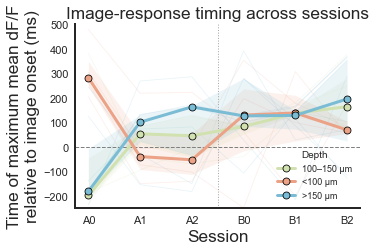

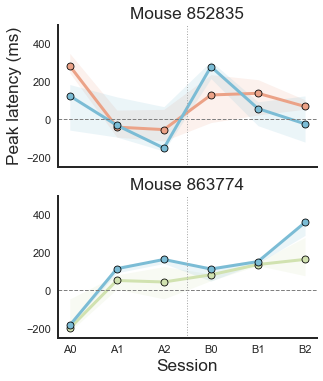

In [5]:
def finish_axis(ax):
    sns.despine(ax=ax); ax.tick_params(axis="both",labelsize=11)
    for spine in ax.spines.values(): spine.set_linewidth(2)

xmap = {s:i for i,s in enumerate(available_labels)}; x = np.arange(len(available_labels))
fig,ax = plt.subplots(figsize=(5.2,3.6))
for (_,cell),g in tracked_peak.groupby(["subject_id","global_cell_id"],observed=True):
    g = g.assign(x=g["session_label"].map(xmap)).dropna(subset=["x"]).sort_values("x")
    if len(g)>1: ax.plot(g["x"],1000*g["peak_latency_s"],color=DEPTH_COLORS[str(g["depth_group"].iloc[0])],lw=.8,alpha=.16,zorder=1)
for group,g in tracked_peak.groupby("depth_group",observed=True):
    q = g.groupby("session_label")["peak_latency_s"].agg(median="median",q25=lambda z:np.nanquantile(z,.25),q75=lambda z:np.nanquantile(z,.75)).reindex(available_labels)
    valid=q["median"].notna().to_numpy(); xx=x[valid]; c=DEPTH_COLORS[str(group)]
    ax.fill_between(xx,1000*q["q25"].to_numpy()[valid],1000*q["q75"].to_numpy()[valid],color=c,alpha=.15,lw=0)
    ax.plot(xx,1000*q["median"].to_numpy()[valid],"-o",color=c,lw=3,ms=7,mec="black",mew=.8,label=str(group),zorder=3)
ax.axhline(0,color=".5",lw=1,ls="--")
if "A2" in xmap and "B0" in xmap: ax.axvline((xmap["A2"]+xmap["B0"])/2,color=".65",lw=1,ls=":")
ax.set(xticks=x,xticklabels=available_labels,xlabel="Session",ylabel="Time of maximum mean dF/F\nrelative to image onset (ms)",ylim=(1000*PEAK_WINDOW_S[0],1000*PEAK_WINDOW_S[1]),title="Image-response timing across sessions")
finish_axis(ax); ax.legend(title="Depth",frameon=False,fontsize=9); fig.tight_layout()
save_figure(fig,os.path.join(SAVE_PATH,"latency_shift"),formats=[".pdf"],dpi=300); plt.show()

mice = sorted(tracked_peak["subject_id"].astype(str).unique())
fig,axs = plt.subplots(len(mice),1,figsize=(4.6,2.7*len(mice)),sharex=True,sharey=True); axs=np.atleast_1d(axs)
for ax,mouse in zip(axs,mice):
    m=tracked_peak[tracked_peak["subject_id"].astype(str)==mouse]
    for group,g in m.groupby("depth_group",observed=True):
        q=g.groupby("session_label")["peak_latency_s"].agg(median="median",q25=lambda z:np.nanquantile(z,.25),q75=lambda z:np.nanquantile(z,.75)).reindex(available_labels)
        valid=q["median"].notna().to_numpy(); xx=x[valid]; c=DEPTH_COLORS[str(group)]
        ax.fill_between(xx,1000*q["q25"].to_numpy()[valid],1000*q["q75"].to_numpy()[valid],color=c,alpha=.15,lw=0)
        ax.plot(xx,1000*q["median"].to_numpy()[valid],"-o",color=c,lw=3,ms=7,mec="black",mew=.8,label=str(group))
    ax.axhline(0,color=".5",lw=1,ls="--")
    if "A2" in xmap and "B0" in xmap: ax.axvline((xmap["A2"]+xmap["B0"])/2,color=".65",lw=1,ls=":")
    ax.set(title=f"Mouse {mouse}",ylim=(1000*PEAK_WINDOW_S[0],1000*PEAK_WINDOW_S[1])); finish_axis(ax)
axs[-1].set(xticks=x,xticklabels=available_labels,xlabel="Session"); axs[0].set_ylabel("Peak latency (ms)")
fig.tight_layout(); save_figure(fig,os.path.join(SAVE_PATH,"latency_shift_by_mouse"),formats=[".pdf"],dpi=300); plt.show()

## Trial-wise image variability

Ordinary image presentations use 0–250 ms firing rate. `RMS²` is the trial-count-weighted between-image firing-rate variance and `FVE = RMS² / total firing-rate variance`.

In [6]:
ordinary_events = events[events["retained_image_window"].astype(bool) & ~events["is_change"].astype(bool) & ~events["is_omission"].astype(bool) & events["image_label"].notna()].copy()
spike_lookup = {(str(sid),int(dmd),int(roi)):np.sort(g["spike_time_sec"].to_numpy(float)) for (sid,dmd,roi),g in spikes.groupby(["session_id","dmd","roi"],observed=True)}
trial_rows=[]; start,stop=IMAGE_WINDOW_S; duration=stop-start
for session in sessions.itertuples(index=False):
    sid=str(session.session_id); ev=ordinary_events[ordinary_events["session_id"].astype(str)==sid][["event_id","onset_sec","image_label","time_block"]]
    onsets=ev["onset_sec"].to_numpy(float)
    for r in rois[(rois["session_id"].astype(str)==sid) & rois["included"].astype(bool)].itertuples(index=False):
        st=spike_lookup.get((sid,int(r.dmd),int(r.roi)),np.array([],float))
        rate=(np.searchsorted(st,onsets+stop,side="left")-np.searchsorted(st,onsets+start,side="left"))/duration
        t=ev.copy(); t["image_rate_hz"]=rate; t["subject_id"]=str(r.subject_id); t["session_id"]=sid; t["session_label"]=str(r.session_label); t["session_order"]=int(r.session_order); t["dmd"]=int(r.dmd); t["roi"]=int(r.roi); t["cell_id"]=str(r.cell_id); t["global_cell_id"]=str(getattr(r,"global_cell_id","")); t["manually_registered"]=bool(getattr(r,"manually_registered",False)); t["depth_um"]=float(r.depth_um); t["depth_group"]=str(r.depth_group)
        trial_rows.append(t)
image_trial_df=pd.concat(trial_rows,ignore_index=True)

metric_keys=["subject_id","session_id","session_label","session_order","dmd","roi","cell_id","global_cell_id","manually_registered","depth_um","depth_group"]
metric_rows=[]
for keys,t in image_trial_df.groupby(metric_keys,observed=True,dropna=False):
    counts=t["image_label"].value_counts(); keep=counts[counts>=MIN_TRIALS_PER_IMAGE].index; q=t[t["image_label"].isin(keep)]
    y=q["image_rate_hz"].to_numpy(float)
    if len(y)<2 or q["image_label"].nunique()<2: continue
    grand=y.mean(); total=np.mean((y-grand)**2); means=q.groupby("image_label")["image_rate_hz"].agg(["mean","size"])
    between=float(np.sum(means["size"]*(means["mean"]-grand)**2)/len(y))
    row=dict(zip(metric_keys,keys)); row.update(mean_rate_hz=float(grand),total_rate_variance_hz2=float(total),identity_rate_variance_hz2=between,image_rms_hz=float(np.sqrt(between)),image_fve=float(between/total) if total>0 else np.nan,n_trials=int(len(y)),n_images=int(len(means)))
    metric_rows.append(row)
image_metrics=pd.DataFrame(metric_rows)
registered_metrics=image_metrics[image_metrics["manually_registered"]].copy()
cell_metrics=registered_metrics.groupby(["subject_id","global_cell_id","depth_group"],observed=True).agg(depth_um=("depth_um","median"),total_rate_variance_hz2=("total_rate_variance_hz2","median"),image_fve=("image_fve","median"),image_rms_hz=("image_rms_hz","median"),n_sessions=("session_id","nunique")).reset_index()
display(image_metrics.head())

,subject_id,session_id,session_label,session_order,dmd,roi,cell_id,global_cell_id,manually_registered,depth_um,depth_group,mean_rate_hz,total_rate_variance_hz2,identity_rate_variance_hz2,image_rms_hz,image_fve,n_trials,n_images
0,852835,852835_2026-07-23_14-27-27,A0,0,1,0,852835_C003,852835_C003,True,40.0,<100 µm,6.475728,49.925139,0.321660,0.567151,0.006443,2060,8
1,852835,852835_2026-07-23_14-27-27,A0,0,1,1,852835_C002,852835_C002,True,40.0,<100 µm,6.324272,63.778343,0.386275,0.621510,0.006057,2060,8
2,852835,852835_2026-07-23_14-27-27,A0,0,1,2,852835_C001,852835_C001,True,40.0,<100 µm,6.417476,110.062607,1.703853,1.305317,0.015481,2060,8
3,852835,852835_2026-07-23_14-27-27,A0,0,1,3,852835_C000,852835_C000,True,40.0,<100 µm,5.524272,56.558149,0.454689,0.674306,0.008039,2060,8
4,852835,852835_2026-07-23_14-27-27,A0,0,2,0,852835_C006,852835_C006,True,170.0,>150 µm,15.477670,143.657268,1.306179,1.142882,0.009092,2060,8


In [7]:
def plot_longitudinal(ax,df,metric,ylabel):
    labels=[s for s in SESSION_ORDER if s in set(df["session_label"].astype(str))]; xm={s:i for i,s in enumerate(labels)}; xx=np.arange(len(labels))
    tracked=df.groupby(["subject_id","global_cell_id"],group_keys=False,observed=True).filter(lambda z:z["session_id"].nunique()>=2)
    for (mouse,cell),g in tracked.groupby(["subject_id","global_cell_id"],observed=True):
        g=g.assign(x=g["session_label"].map(xm)).dropna(subset=["x"]).sort_values("x")
        if len(g)>1: ax.plot(g["x"],g[metric],color=DEPTH_COLORS[str(g["depth_group"].iloc[0])],lw=.8,alpha=.12,zorder=1)
    for (mouse,group),g in df.groupby(["subject_id","depth_group"],observed=True):
        q=g.groupby("session_label")[metric].agg(median="median",q25=lambda z:np.nanquantile(z,.25),q75=lambda z:np.nanquantile(z,.75)).reindex(labels)
        valid=q["median"].notna().to_numpy(); xq=xx[valid]
        if not valid.any(): continue
        c=DEPTH_COLORS[str(group)]; marker=MOUSE_MARKERS.get(str(mouse),"o")
        ax.fill_between(xq,q["q25"].to_numpy()[valid],q["q75"].to_numpy()[valid],color=c,alpha=.12,lw=0,zorder=2)
        ax.plot(xq,q["median"].to_numpy()[valid],color=c,marker=marker,ms=7,mec="black",mew=.8,lw=3,zorder=3)
    if "A2" in xm and "B0" in xm: ax.axvline((xm["A2"]+xm["B0"])/2,color=".65",lw=1,ls=":")
    ax.set(xticks=xx,xticklabels=labels,xlabel="Session",ylabel=ylabel); finish_axis(ax)

def add_legends(ax):
    depth=[Line2D([0],[0],color=DEPTH_COLORS[g],lw=3,marker="o",mec="black",mew=.6,label=g) for g in DEPTH_GROUP_ORDER]
    mouse=[Line2D([0],[0],color=".35",lw=0,marker=MOUSE_MARKERS.get(str(m),"o"),ms=7,mec="black",label=str(m)) for m in TARGET_MICE]
    l1=ax.legend(handles=depth,title="Depth",frameon=False,fontsize=8,loc="upper left"); ax.add_artist(l1)
    ax.legend(handles=mouse,title="Mouse",frameon=False,fontsize=8,loc="upper right")

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_47328\242036354.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cell_metrics,x="depth_group",y="total_rate_variance_hz2",order=order,palette=DEPTH_COLORS,inner=None,width=.5,linewidth=1.5,ax=axs[0])


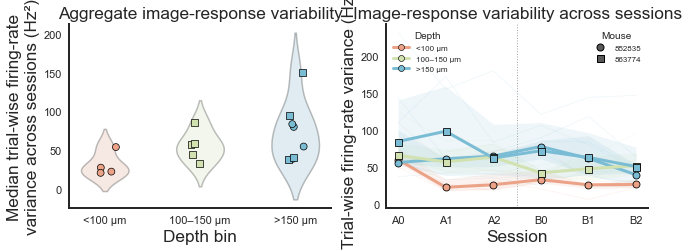

In [10]:
fig,axs=plt.subplots(1,2,figsize=(9.2,3.6))
order=[g for g in DEPTH_GROUP_ORDER if g in set(cell_metrics["depth_group"].astype(str))]
sns.violinplot(data=cell_metrics,x="depth_group",y="total_rate_variance_hz2",order=order,palette=DEPTH_COLORS,inner=None,width=.5,linewidth=1.5,ax=axs[0])
for coll in axs[0].collections: coll.set_alpha(.25); coll.set_edgecolor("black")
rng=np.random.default_rng(8)
for mouse,g in cell_metrics.groupby("subject_id",observed=True):
    xpos=np.array([order.index(str(x)) for x in g["depth_group"]],float)+rng.uniform(-.12,.12,len(g))
    axs[0].scatter(xpos,g["total_rate_variance_hz2"],s=48,c=[DEPTH_COLORS[str(x)] for x in g["depth_group"]],marker=MOUSE_MARKERS.get(str(mouse),"o"),edgecolor="black",linewidth=.7,zorder=3)
axs[0].set(xlabel="Depth bin",ylabel="Median trial-wise firing-rate\nvariance across sessions (Hz²)",title="Aggregate image-response variability"); finish_axis(axs[0])

plot_longitudinal(axs[1],registered_metrics,"total_rate_variance_hz2","Trial-wise firing-rate variance (Hz²)")
axs[1].set_title("Image-response variability across sessions"); add_legends(axs[1])
fig.tight_layout(); save_figure(fig,os.path.join(SAVE_PATH,"image_trial_variance"),formats=[".pdf"],dpi=300); plt.show()

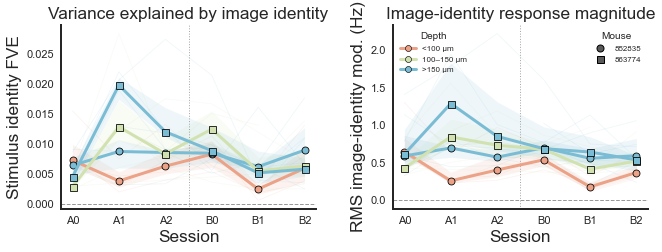

,subject_id,session_label,global_cell_id,depth_group,mean_rate_hz,total_rate_variance_hz2,identity_rate_variance_hz2,image_fve,image_rms_hz,n_trials,n_images
3,852835,A0,852835_C000,<100 µm,5.524272,56.558149,0.454689,0.008039,0.674306,2060,8
2,852835,A0,852835_C001,<100 µm,6.417476,110.062607,1.703853,0.015481,1.305317,2060,8
1,852835,A0,852835_C002,<100 µm,6.324272,63.778343,0.386275,0.006057,0.621510,2060,8
0,852835,A0,852835_C003,<100 µm,6.475728,49.925139,0.321660,0.006443,0.567151,2060,8
6,852835,A0,852835_C004,>150 µm,3.732039,54.685478,0.349983,0.006400,0.591594,2060,8
...,...,...,...,...,...,...,...,...,...,...,...
97,863774,B2,863774_C004,100–150 µm,5.467926,60.540369,0.836173,0.013812,0.914425,2011,8
91,863774,B2,863774_C005,>150 µm,3.065142,24.840610,0.269844,0.010863,0.519465,2011,8
92,863774,B2,863774_C006,>150 µm,12.312282,146.718989,0.509696,0.003474,0.713930,2011,8
94,863774,B2,863774_C007,>150 µm,8.262556,53.762989,0.266696,0.004961,0.516426,2011,8


In [17]:
fig,axs=plt.subplots(1,2,figsize=(9.2,3.6))
plot_longitudinal(axs[0],registered_metrics,"image_fve","Stimulus identity FVE")
plot_longitudinal(axs[1],registered_metrics,"image_rms_hz","RMS image-identity mod. (Hz)")
axs[0].axhline(0,color=".6",lw=1,ls="--"); axs[1].axhline(0,color=".6",lw=1,ls="--")
axs[0].set_title("Variance explained by image identity"); axs[1].set_title("Image-identity response magnitude")
add_legends(axs[1]); fig.tight_layout()
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
save_figure(fig,os.path.join(SAVE_PATH,"image_identity_fve_rms"),formats=[".pdf"],dpi=300); plt.show()
display(
    image_metrics
    .sort_values(["subject_id","session_order","depth_um","global_cell_id"])
    [["subject_id","session_label","global_cell_id","depth_group","mean_rate_hz","total_rate_variance_hz2","identity_rate_variance_hz2","image_fve","image_rms_hz","n_trials","n_images"]]
)